In [ ]:
!pip install pandas matplotlib seaborn openpyxl -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

# Global style — apply once, affects all charts
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'figure.dpi': 120
})

In [ ]:
# Load every file — run this once, use the variables in every chart cell below
retention_pivot    = pd.read_csv('/retention_pivot.csv')
retention_matrix   = pd.read_csv('/retention_matrix.csv')
kpi1_churn         = pd.read_csv('/KPI1.csv')
kpi2_repurchase    = pd.read_csv('/KPI2.csv')
kpi3_revenue       = pd.read_csv('/KPI3.csv')
kpi4_acquisition   = pd.read_csv('/KPI4.csv')
kpi5_aov           = pd.read_csv('/KPI5.csv')
kpi6_seasonal      = pd.read_csv('/KPI6.csv')
kpi7_states        = pd.read_csv('/KPI7.csv')
kpi8_dense         = pd.read_csv('/KPI8.csv')
kpi9_ntile         = pd.read_csv('/KPI9.csv')
kpi10_payment      = pd.read_csv('/KPI10.csv')

print("All files loaded.")
for name, df in [('kpi1',kpi1_churn),('kpi2',kpi2_repurchase),('kpi3',kpi3_revenue),
                 ('kpi4',kpi4_acquisition),('kpi9',kpi9_ntile),('kpi10',kpi10_payment)]:
    print(f"{name}: {list(df.columns)}")

All files loaded.
kpi1: ['cohort_month', 'cohort_size', 'one_time_buyers', 'repeat_buyers', 'churn_rate_pct', 'repeat_rate_pct']
kpi2: ['repeat_customers', 'avg_days_to_repurchase', 'median_days', 'p25_days', 'p75_days']
kpi3: ['customer_type', 'customer_count', 'order_count', 'total_revenue', 'revenue_share_pct', 'avg_order_value']
kpi4: ['acquisition_month', 'new_customers', 'cohort_first_month_revenue', 'avg_first_order_value', 'cumulative_customers']
kpi9: ['spend_quartile', 'segment_label', 'customer_count', 'min_spend', 'max_spend', 'avg_spend', 'total_segment_revenue', 'revenue_share_pct']
kpi10: ['cohort_month', 'payment_type', 'orders_count', 'total_payment_value', 'avg_payment_value', 'pct_of_cohort_orders']


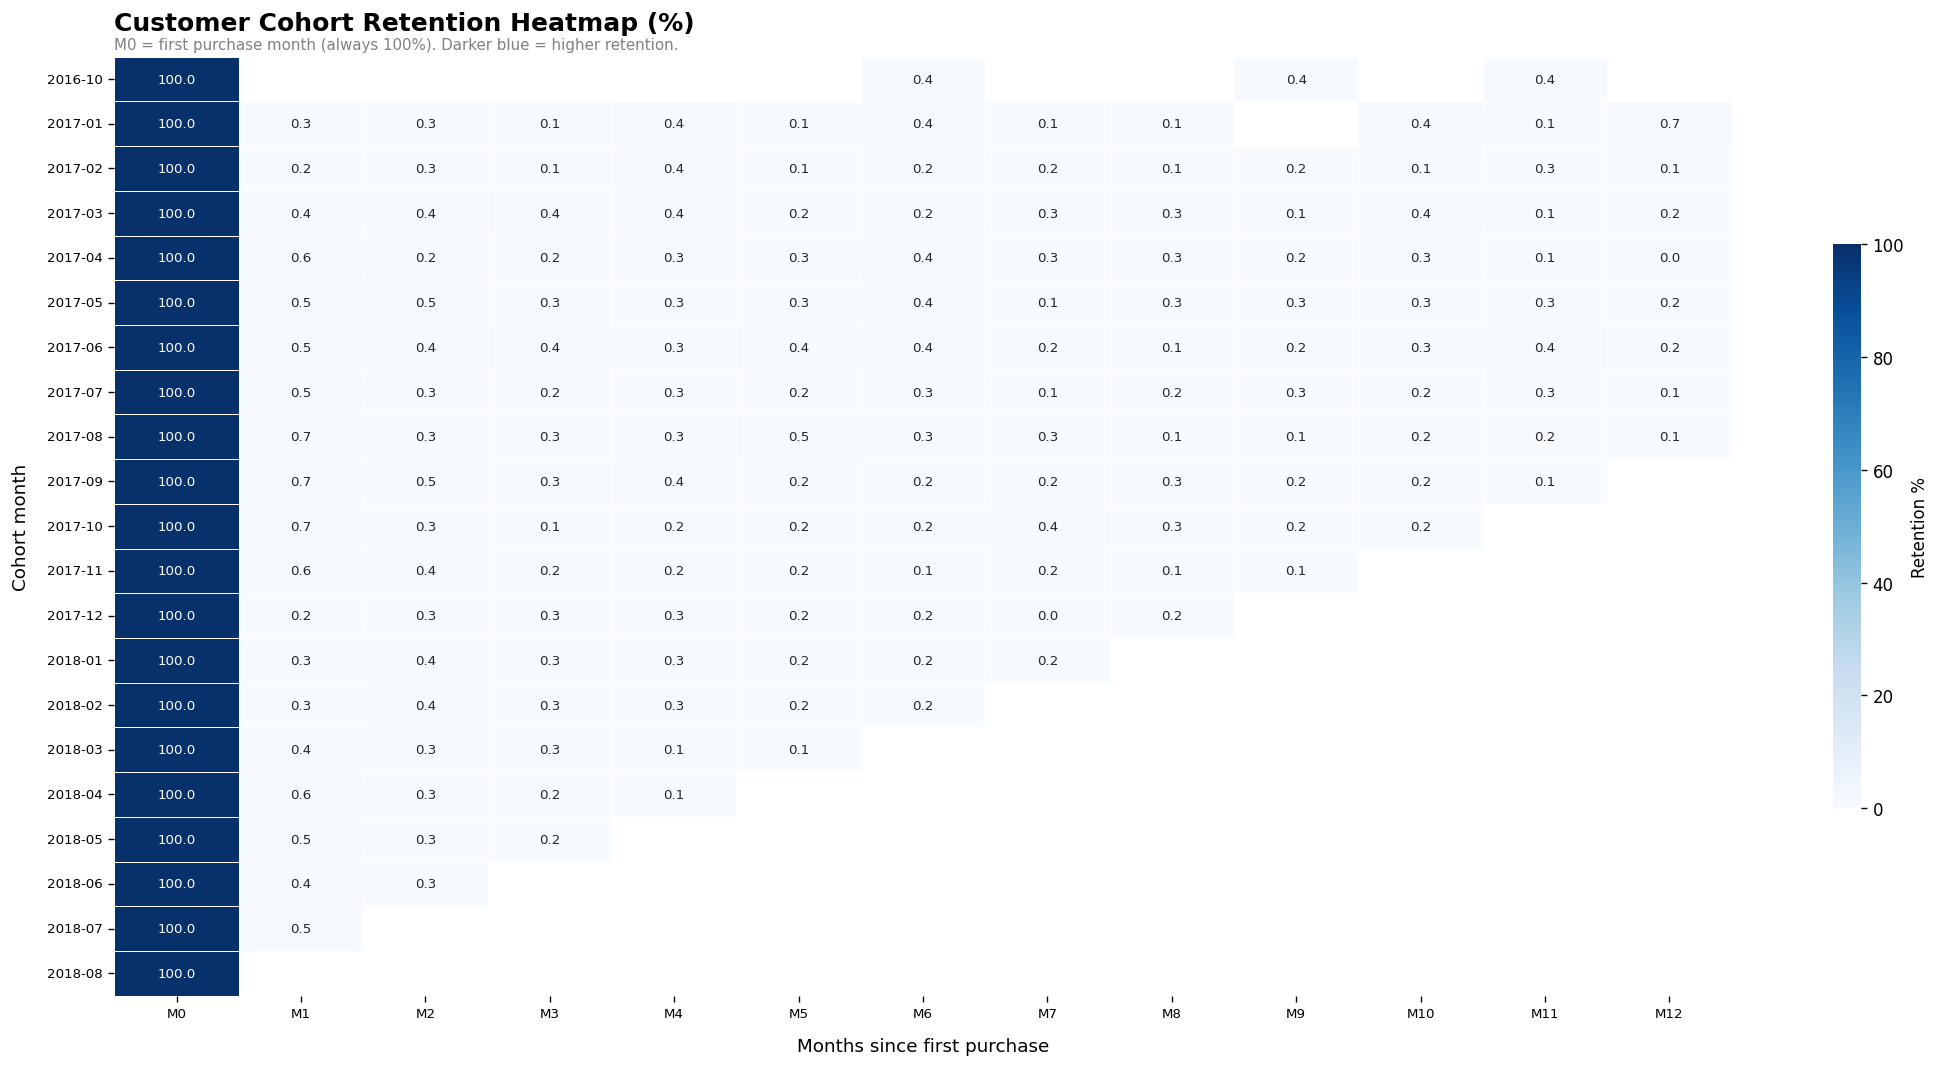

Saved: chart1_heatmap.png


In [ ]:
# CHART 1

df = retention_pivot.copy()
df = df.set_index('cohort_month')
df = df.drop(columns=['cohort_size'], errors='ignore')

# Rename month columns to clean labels
month_cols = [c for c in df.columns]
df.columns = [f'M{i}' for i in range(len(month_cols))]

fig, ax = plt.subplots(figsize=(18, 9))

sns.heatmap(
    df,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.4,
    linecolor='white',
    vmin=0, vmax=100,
    mask=df.isnull(),           # hides NaN cells cleanly
    annot_kws={'size': 8},
    ax=ax,
    cbar_kws={'label': 'Retention %', 'shrink': 0.6}
)

ax.set_title('Customer Cohort Retention Heatmap (%)',
             fontsize=15, fontweight='bold', loc='left', pad=16)
ax.set_xlabel('Months since first purchase', fontsize=11, labelpad=10)
ax.set_ylabel('Cohort month', fontsize=11, labelpad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

fig.text(0.0, 1.005,
    'M0 = first purchase month (always 100%). Darker blue = higher retention.',
    fontsize=9, color='gray', transform=ax.transAxes, va='bottom')

plt.tight_layout()
plt.savefig('chart1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart1_heatmap.png")

['cohort_month', 'cohort_size', 'months_since_first', 'active_customers', 'retention_pct']
Selected cohorts: ['2016-10', '2017-02', '2017-05', '2017-08', '2017-11']


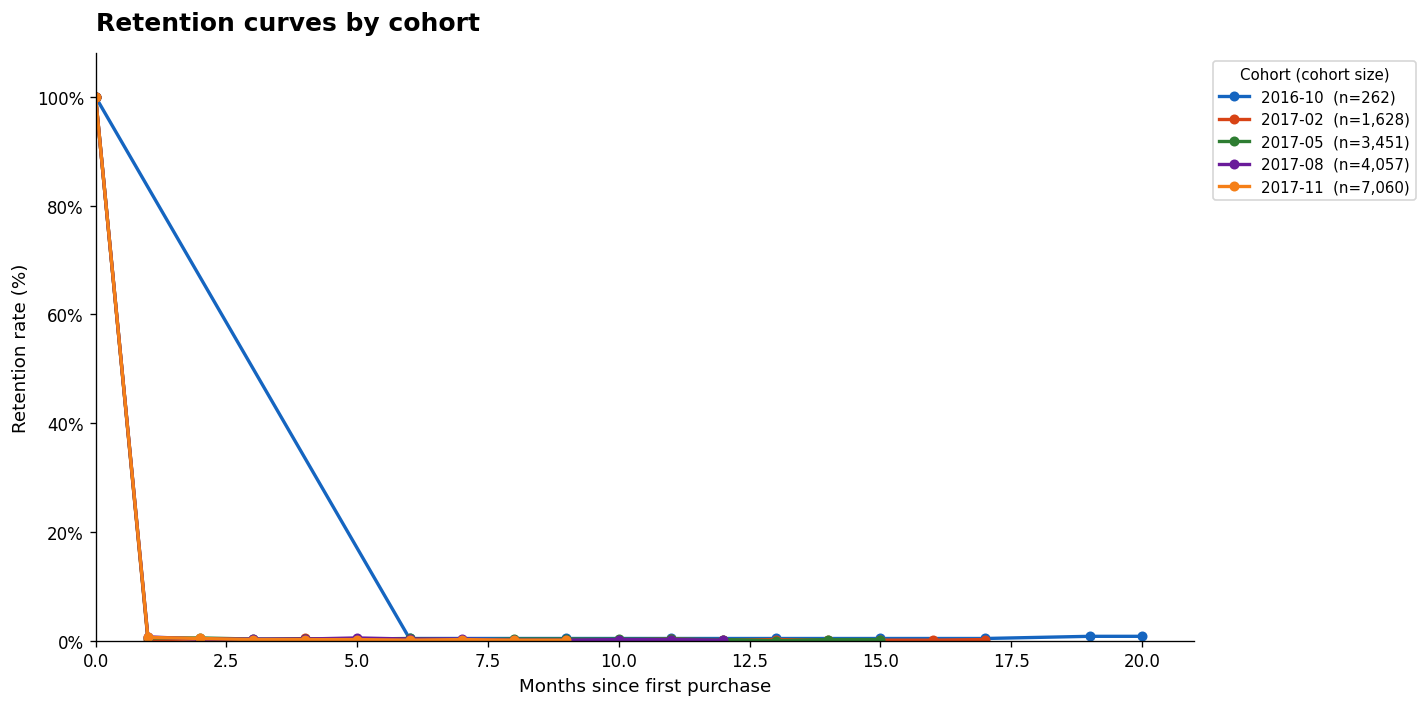

Saved: chart2_retention_curves.png


In [ ]:
# CHART 2

df = retention_matrix.copy()
print(df.columns.tolist())   # confirm: cohort_month, months_since_first, retention_pct, cohort_size

# Pick cohorts with full history — avoid last 4 months of dataset
all_cohorts = sorted(df['cohort_month'].unique())
eligible = all_cohorts[:-4]                        # drops the 4 most recent cohorts

# Pick 5 evenly spaced across the timeline
step = max(1, len(eligible) // 5)
selected = eligible[::step][:5]
print("Selected cohorts:", selected)

filtered = df[df['cohort_month'].isin(selected)].copy()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#1565C0', '#D84315', '#2E7D32', '#6A1B9A', '#F57F17']

for i, (cohort, grp) in enumerate(filtered.groupby('cohort_month')):
    grp = grp.sort_values('months_since_first')
    size = int(grp['cohort_size'].iloc[0])
    ax.plot(grp['months_since_first'], grp['retention_pct'],
            marker='o', markersize=5, linewidth=2,
            color=colors[i], label=f'{cohort}  (n={size:,})')

ax.set_title('Retention curves by cohort',
             fontsize=15, fontweight='bold', loc='left', pad=14)
ax.set_xlabel('Months since first purchase', fontsize=11)
ax.set_ylabel('Retention rate (%)', fontsize=11)
ax.set_xlim(left=0)
ax.set_ylim(0, 108)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend(title='Cohort (cohort size)', fontsize=9, title_fontsize=9,
          bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('chart2_retention_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart2_retention_curves.png")

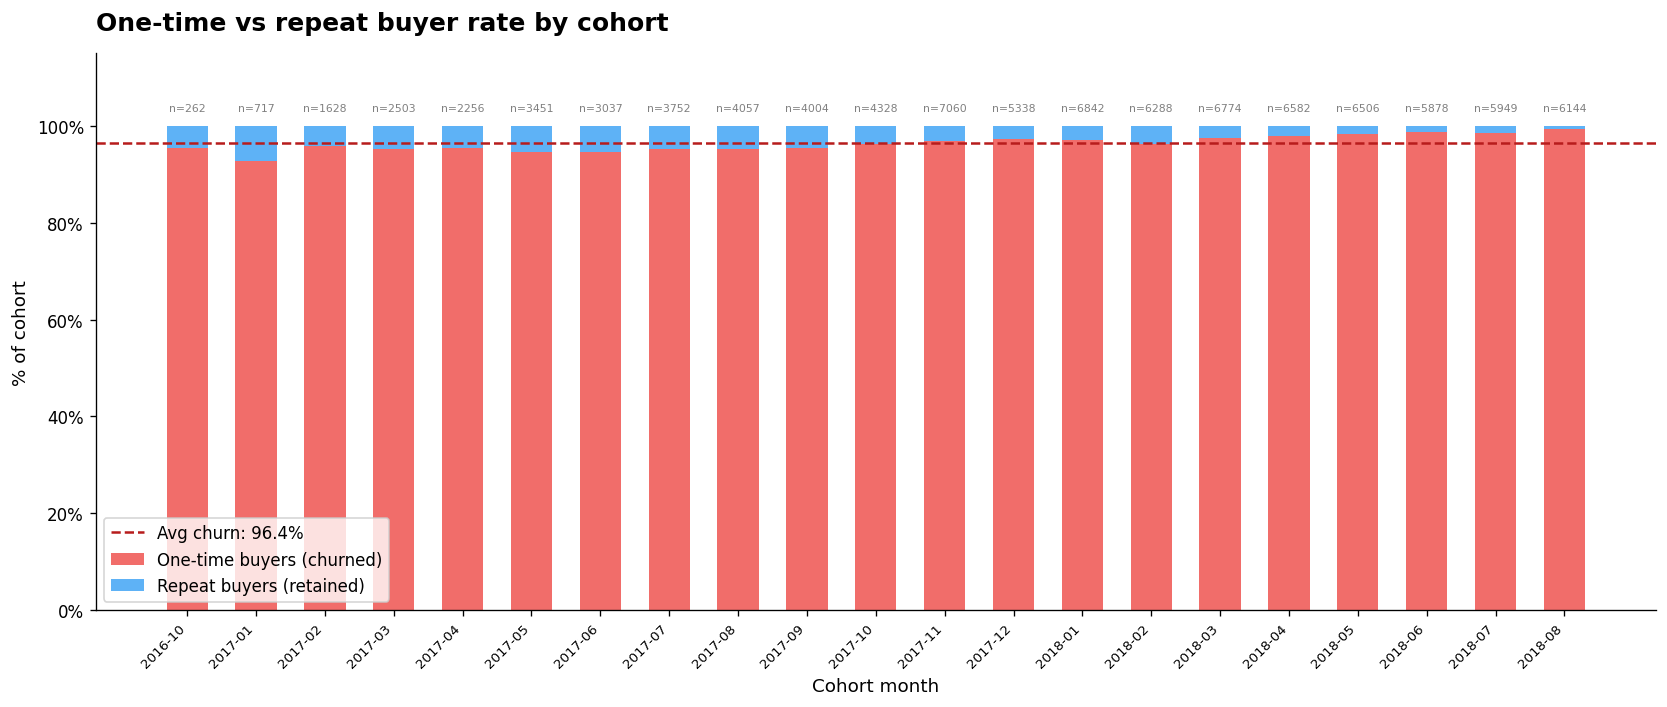

Saved: chart3_churn.png


In [ ]:
# CHART 3

df = kpi1_churn.copy()
df = df[df['cohort_size'] >= 50].sort_values('cohort_month')

x = range(len(df))
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x, df['churn_rate_pct'],  label='One-time buyers (churned)',
       color='#EF5350', alpha=0.85, width=0.6)
ax.bar(x, df['repeat_rate_pct'], label='Repeat buyers (retained)',
       bottom=df['churn_rate_pct'],
       color='#42A5F5', alpha=0.85, width=0.6)

avg = df['churn_rate_pct'].mean()
ax.axhline(avg, color='#B71C1C', linestyle='--', linewidth=1.5,
           label=f'Avg churn: {avg:.1f}%')

ax.set_title('One-time vs repeat buyer rate by cohort',
             fontsize=15, fontweight='bold', loc='left', pad=14)
ax.set_xlabel('Cohort month', fontsize=11)
ax.set_ylabel('% of cohort', fontsize=11)
ax.set_xticks(list(x))
ax.set_xticklabels(df['cohort_month'].tolist(), rotation=45, ha='right', fontsize=8)
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend(fontsize=10)

# Show cohort size above each bar
for i, row in enumerate(df.itertuples()):
    ax.text(i, 103, f'n={row.cohort_size}', ha='center', fontsize=6.5, color='gray')

plt.tight_layout()
plt.savefig('chart3_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart3_churn.png")

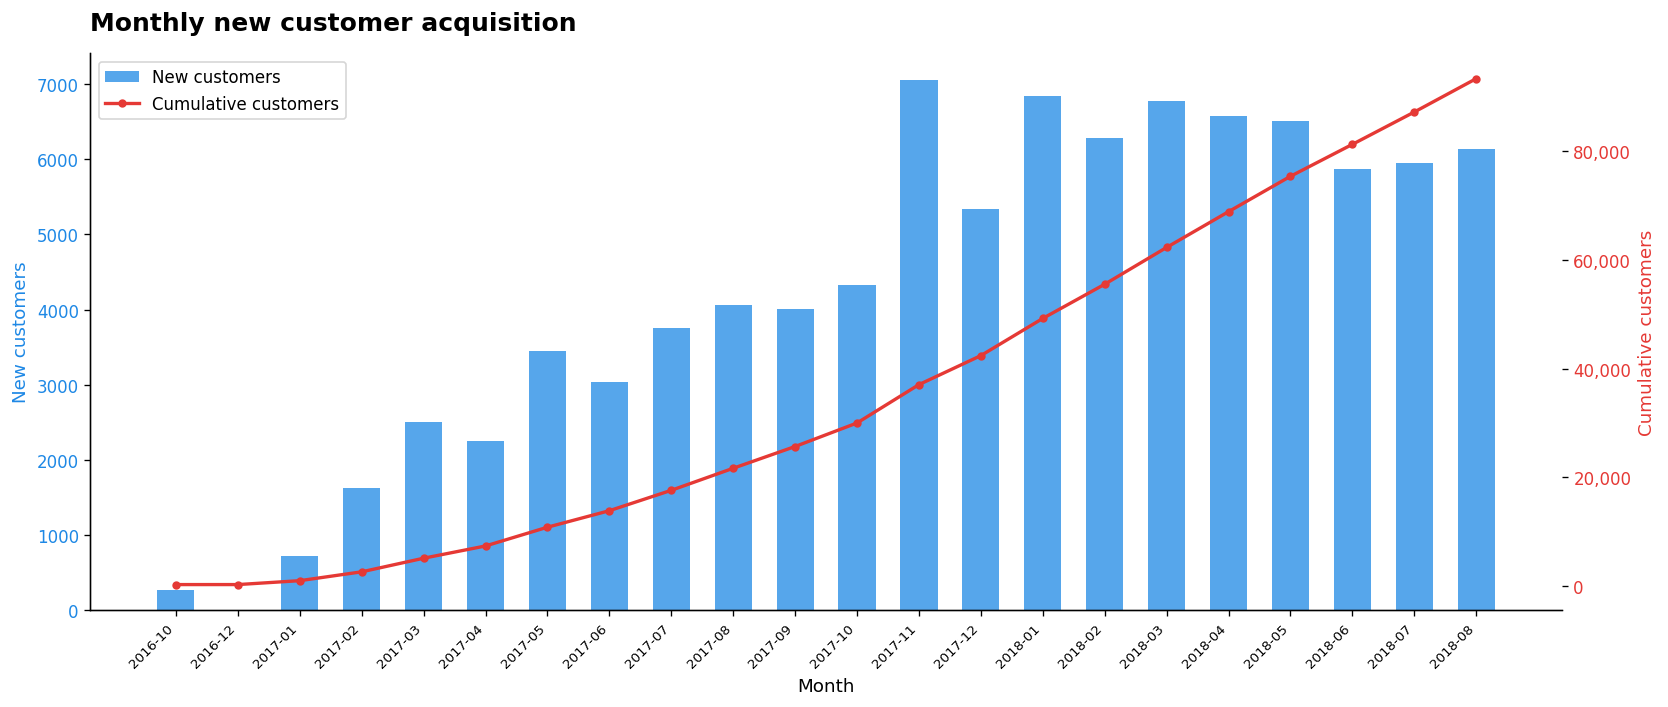

Saved: chart4_acquisition.png


In [ ]:
# CHART 4

df = kpi4_acquisition.copy()
df = df.sort_values('acquisition_month')

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart — new customers per month (left y-axis)
bars = ax1.bar(range(len(df)), df['new_customers'],
               color='#1E88E5', alpha=0.75, width=0.6, label='New customers')

ax1.set_title('Monthly new customer acquisition',
              fontsize=15, fontweight='bold', loc='left', pad=14)
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('New customers', fontsize=11, color='#1E88E5')
ax1.tick_params(axis='y', labelcolor='#1E88E5')
ax1.set_xticks(range(len(df)))
ax1.set_xticklabels(df['acquisition_month'].tolist(), rotation=45, ha='right', fontsize=8)

# Line chart — cumulative customers (right y-axis)
ax2 = ax1.twinx()
ax2.plot(range(len(df)), df['cumulative_customers'],
         color='#E53935', linewidth=2, marker='o', markersize=4,
         label='Cumulative customers')
ax2.set_ylabel('Cumulative customers', fontsize=11, color='#E53935')
ax2.tick_params(axis='y', labelcolor='#E53935')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('chart4_acquisition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart4_acquisition.png")

   repeat_customers  avg_days_to_repurchase  median_days  p25_days  p75_days
0              2801                    81.2           29         0       126


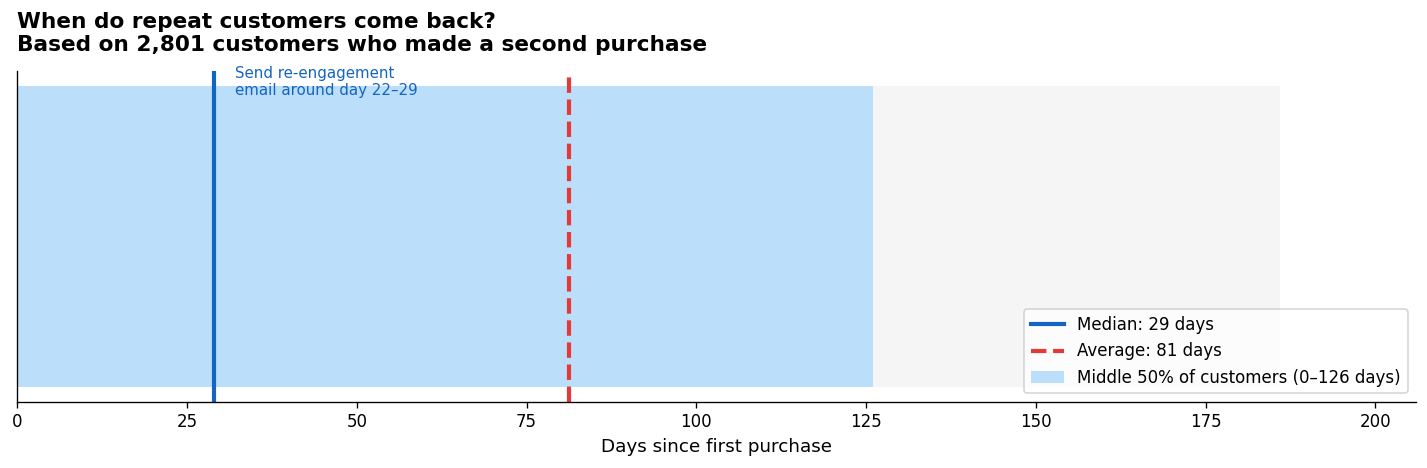

Saved: chart5_repurchase_window.png


In [ ]:
# CHART 5

df = kpi2_repurchase.copy()
print(df)   # this is a single-row CSV — confirm it looks right

avg_days   = float(df['avg_days_to_repurchase'].iloc[0])
median_days = float(df['median_days'].iloc[0])
p25        = float(df['p25_days'].iloc[0])
p75        = float(df['p75_days'].iloc[0])
n_customers = int(df['repeat_customers'].iloc[0])

fig, ax = plt.subplots(figsize=(12, 4))

# IQR band (p25 to p75)
ax.barh(['Repurchase window'], [p75 - p25], left=p25,
        color='#BBDEFB', height=0.35, label=f'Middle 50% of customers ({p25:.0f}–{p75:.0f} days)')

# Full background bar
ax.barh(['Repurchase window'], [max(p75, avg_days) + 60], color='#F5F5F5', height=0.35, zorder=0)

# Median line
ax.axvline(median_days, color='#1565C0', linewidth=2.5,
           label=f'Median: {median_days:.0f} days')

# Average line
ax.axvline(avg_days, color='#E53935', linewidth=2.5, linestyle='--',
           label=f'Average: {avg_days:.0f} days')

ax.set_xlim(0, max(p75, avg_days) + 80)
ax.set_xlabel('Days since first purchase', fontsize=11)
ax.set_yticks([])
ax.set_title(
    f'When do repeat customers come back?\n'
    f'Based on {n_customers:,} customers who made a second purchase',
    fontsize=13, fontweight='bold', loc='left', pad=12)
ax.legend(fontsize=10, loc='lower right')

# Annotation for business insight
ax.text(median_days + 3, 0.18,
        f'Send re-engagement\nemail around day {int(median_days)-7}–{int(median_days)}',
        fontsize=9, color='#1565C0', va='center')

plt.tight_layout()
plt.savefig('chart5_repurchase_window.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart5_repurchase_window.png")

  customer_type  customer_count  order_count  total_revenue  \
0        repeat            2801         5921      864357.21   
1      one_time           90556        90556    14558104.56   

   revenue_share_pct  avg_order_value  
0                5.6           145.98  
1               94.4           160.76  


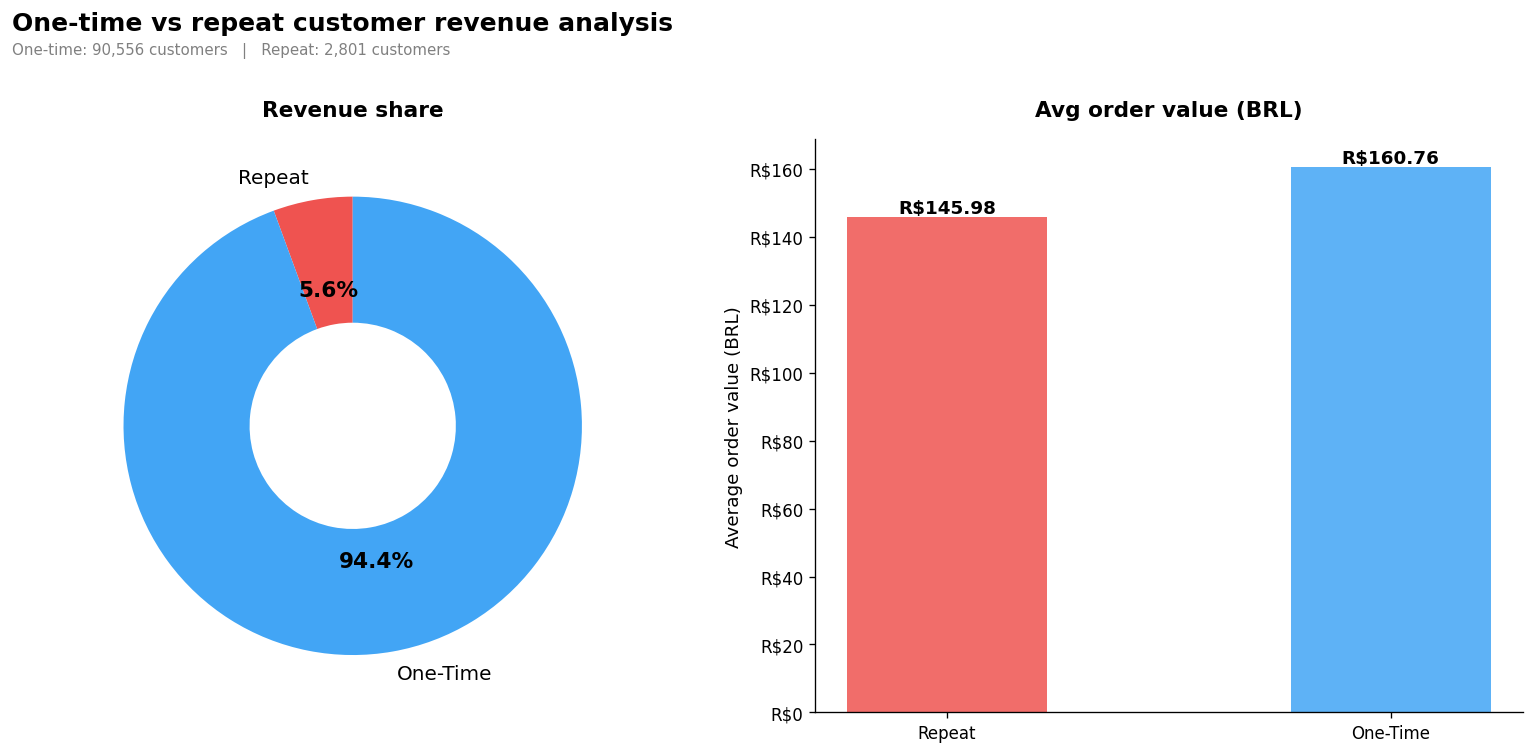

Saved: chart6_revenue_split.png


In [ ]:
# CHART 6

df = kpi3_revenue.copy()
print(df)   # 2-row CSV: one_time and repeat

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

colors = ['#EF5350', '#42A5F5']   # red = one-time, blue = repeat
labels = df['customer_type'].str.replace('_', '-').str.title().tolist()

# Left: donut chart — revenue share
wedges, texts, autotexts = axes[0].pie(
    df['revenue_share_pct'],
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.55},   # this makes it a donut
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
axes[0].set_title('Revenue share', fontsize=13, fontweight='bold', pad=14)

# Right: bar chart — avg order value comparison
bars = axes[1].bar(labels, df['avg_order_value'], color=colors, width=0.45, alpha=0.85)
axes[1].set_title('Avg order value (BRL)', fontsize=13, fontweight='bold', pad=14)
axes[1].set_ylabel('Average order value (BRL)', fontsize=11)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'R${x:,.0f}'))

for bar, val in zip(bars, df['avg_order_value']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'R${val:,.2f}',
                 ha='center', fontsize=11, fontweight='bold')

fig.suptitle('One-time vs repeat customer revenue analysis',
             fontsize=15, fontweight='bold', x=0.02, ha='left', y=1.04)

# Add customer count as subtitle
one_n = int(df[df['customer_type']=='one_time']['customer_count'].iloc[0])
rep_n = int(df[df['customer_type']=='repeat']['customer_count'].iloc[0])
fig.text(0.02, 0.98, f'One-time: {one_n:,} customers   |   Repeat: {rep_n:,} customers',
         fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('chart6_revenue_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart6_revenue_split.png")

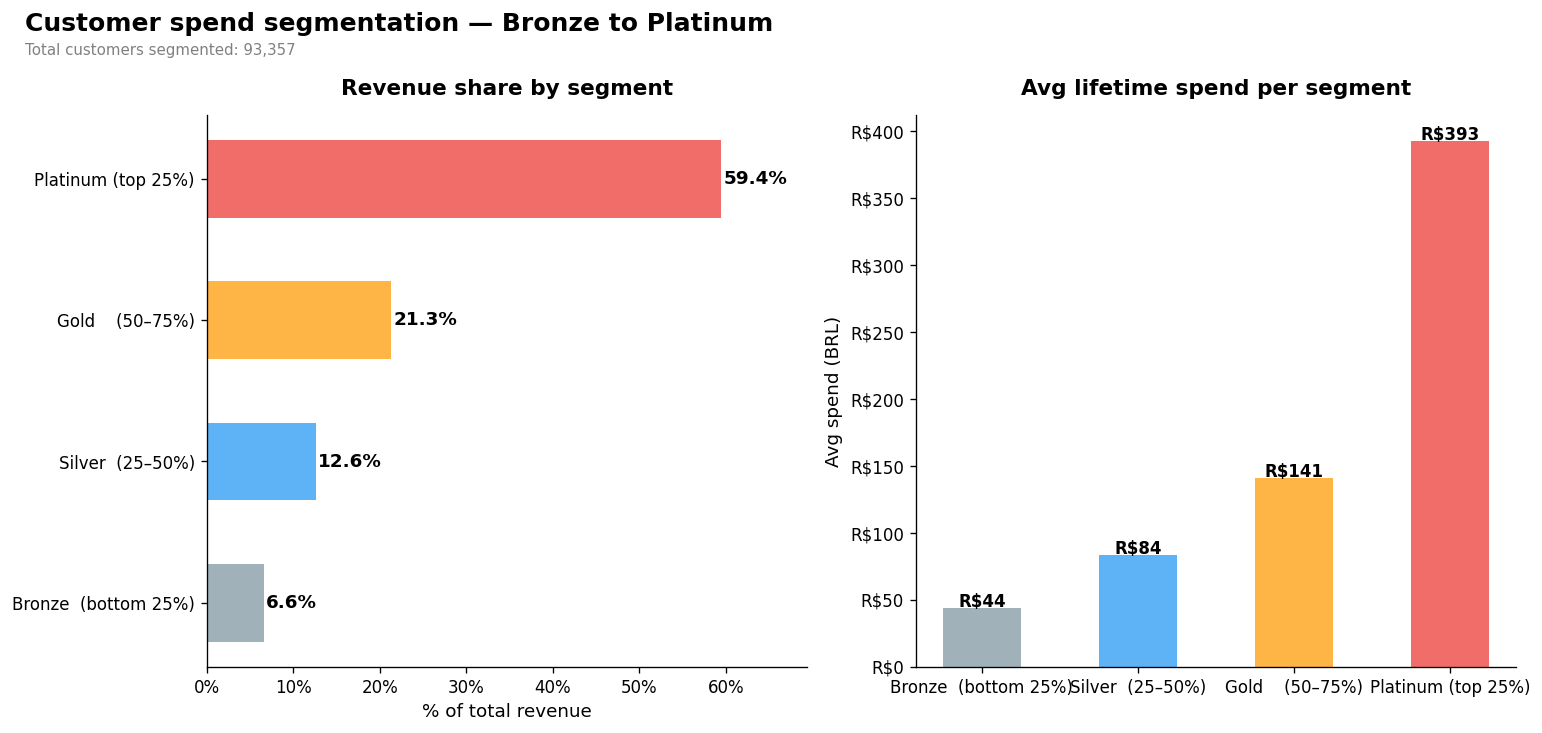

Saved: chart7_segments.png


In [ ]:
# CHART 7

df = kpi9_ntile.copy()
df = df.sort_values('spend_quartile') if 'spend_quartile' in df.columns else df

labels = df['segment_label'].str.strip().tolist()
seg_colors = ['#90A4AE', '#42A5F5', '#FFA726', '#EF5350']
# Bronze=gray, Silver=blue, Gold=amber, Platinum=red

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Left: horizontal bar — revenue share per segment
bars = axes[0].barh(labels, df['revenue_share_pct'],
                    color=seg_colors, alpha=0.85, height=0.55)
axes[0].set_title('Revenue share by segment', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('% of total revenue', fontsize=11)
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
for bar, val in zip(bars, df['revenue_share_pct']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
axes[0].set_xlim(0, df['revenue_share_pct'].max() + 10)

# Right: bar — avg spend per segment
bars2 = axes[1].bar(labels, df['avg_spend'], color=seg_colors, alpha=0.85, width=0.5)
axes[1].set_title('Avg lifetime spend per segment', fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel('Avg spend (BRL)', fontsize=11)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'R${x:,.0f}'))
for bar, val in zip(bars2, df['avg_spend']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'R${val:,.0f}',
                 ha='center', fontsize=10, fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Customer spend segmentation — Bronze to Platinum',
             fontsize=15, fontweight='bold', x=0.02, ha='left', y=1.01)

n_total = int(df['customer_count'].sum())
fig.text(0.02, 0.95, f'Total customers segmented: {n_total:,}', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('chart7_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart7_segments.png")

               season  months_since_first  cohorts_in_season  \
0   holiday (Nov–Dec)                   1                  2   
1  mid-year (Jun–Aug)                   1                  5   
2             regular                   1                 12   
3   holiday (Nov–Dec)                   2                  2   
4  mid-year (Jun–Aug)                   2                  4   

   avg_retention_pct  
0               0.40  
1               0.52  
2               0.46  
3               0.35  
4               0.32  
['holiday (Nov–Dec)' 'mid-year (Jun–Aug)' 'regular']


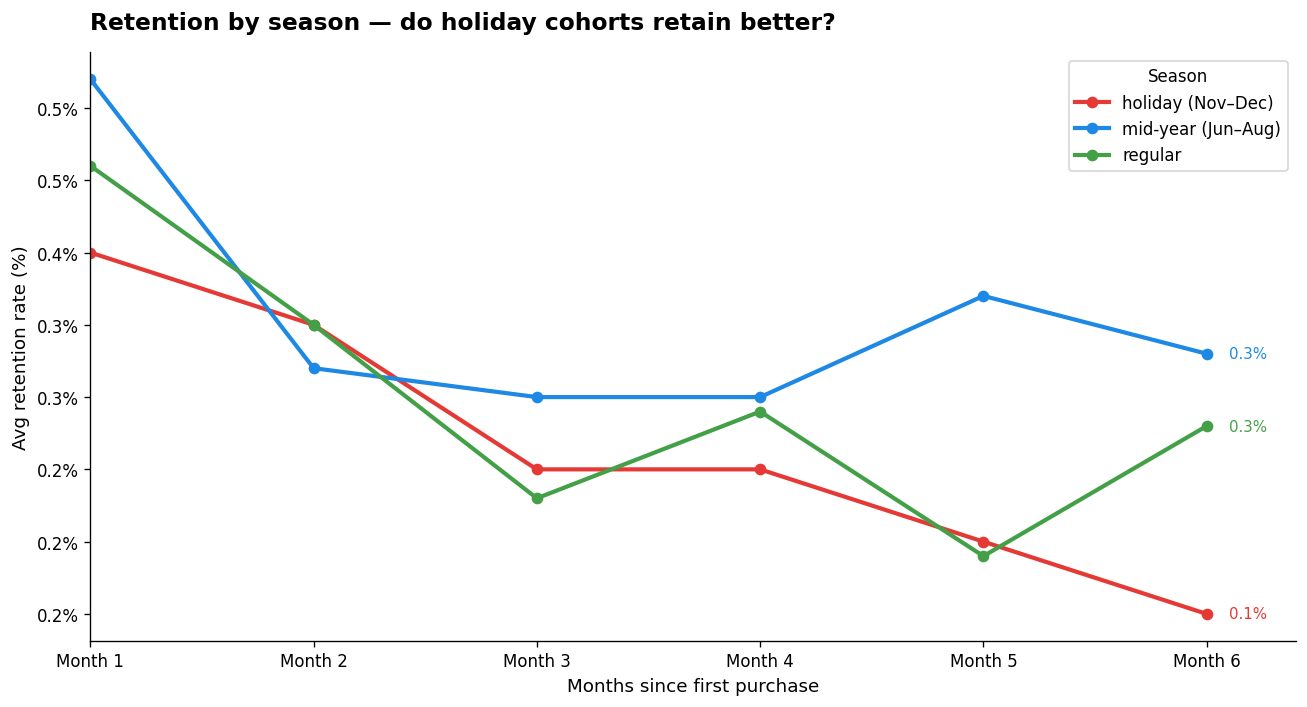

Saved: chart8_seasonal.png


In [ ]:
# CHART 8

df = kpi6_seasonal.copy()
print(df.head())
print(df['season'].unique())   # check exact season label names

fig, ax = plt.subplots(figsize=(11, 6))

season_colors = {
    'holiday (Nov–Dec)': '#E53935',
    'mid-year (Jun–Aug)': '#1E88E5',
    'regular':            '#43A047',
}
# If your season names differ slightly, update the keys above to match

for season, grp in df.groupby('season'):
    grp = grp.sort_values('months_since_first')
    color = season_colors.get(season, '#888888')
    ax.plot(grp['months_since_first'], grp['avg_retention_pct'],
            marker='o', markersize=6, linewidth=2.5,
            color=color, label=season)
    # Label end of each line
    last = grp.iloc[-1]
    ax.text(last['months_since_first'] + 0.1, last['avg_retention_pct'],
            f"{last['avg_retention_pct']:.1f}%", fontsize=9, color=color, va='center')

ax.set_title('Retention by season — do holiday cohorts retain better?',
             fontsize=14, fontweight='bold', loc='left', pad=14)
ax.set_xlabel('Months since first purchase', fontsize=11)
ax.set_ylabel('Avg retention rate (%)', fontsize=11)
ax.set_xlim(1, 6.4)
ax.set_xticks(range(1, 7))
ax.set_xticklabels([f'Month {i}' for i in range(1, 7)])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.legend(title='Season', fontsize=10, title_fontsize=10)

plt.tight_layout()
plt.savefig('chart8_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart8_seasonal.png")

['credit_card' 'boleto' 'voucher' 'debit_card']


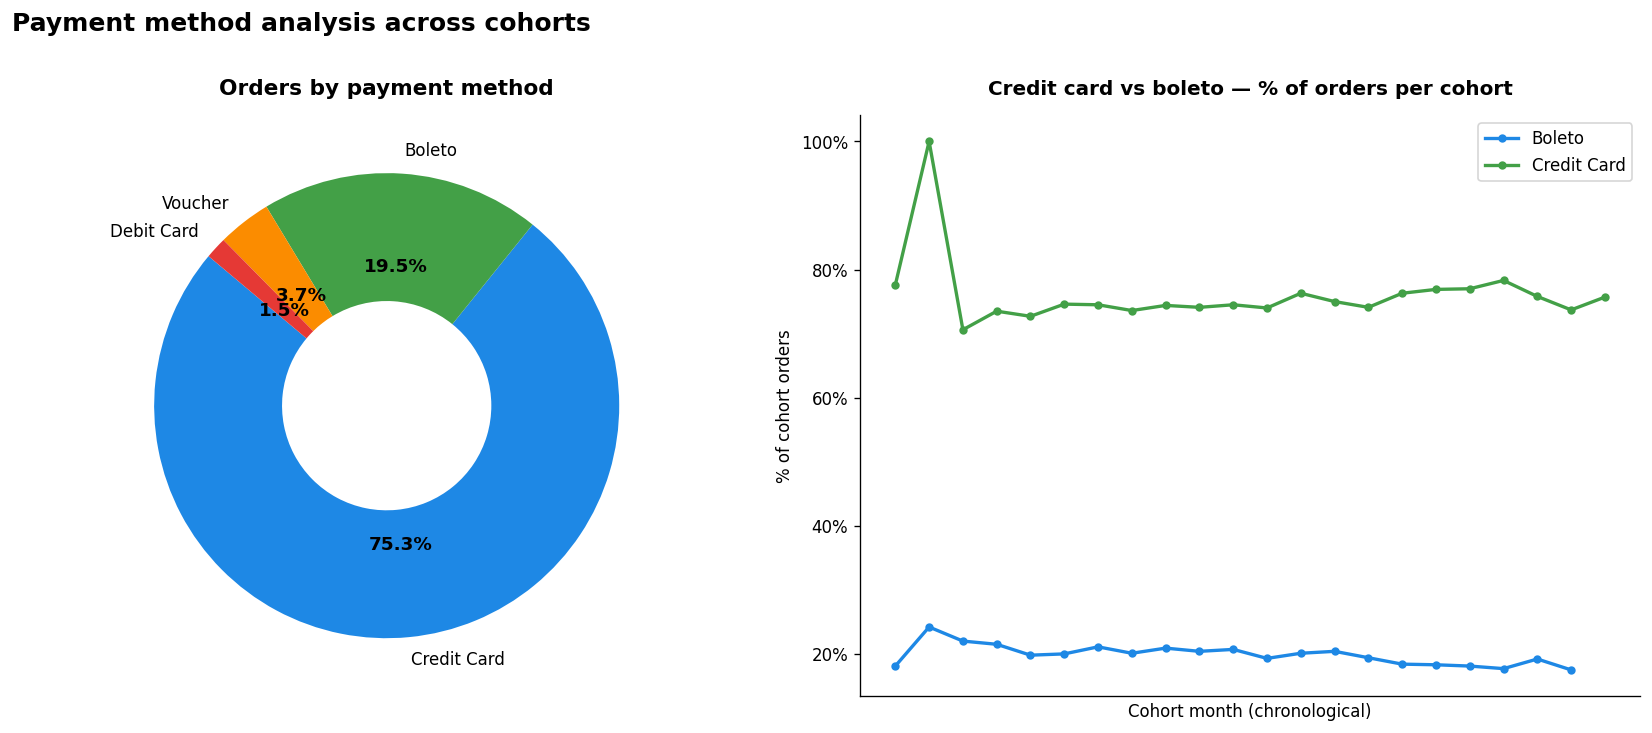

Saved: chart9_payment.png


In [ ]:
# CHART 9

df = kpi10_payment.copy()
print(df['payment_type'].unique())   # check exact payment type names

# Aggregate across all cohorts for an overall view
overall = (df.groupby('payment_type')
             .agg(total_orders=('orders_count','sum'),
                  total_revenue=('total_payment_value','sum'))
             .reset_index()
             .sort_values('total_orders', ascending=False))

overall['order_share_pct'] = overall['total_orders'] / overall['total_orders'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pay_colors = ['#1E88E5','#43A047','#FB8C00','#E53935','#8E24AA']

# Left: donut — order share by payment type
wedges, texts, autotexts = axes[0].pie(
    overall['order_share_pct'],
    labels=overall['payment_type'].str.replace('_',' ').str.title(),
    colors=pay_colors[:len(overall)],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'width': 0.55},
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[0].set_title('Orders by payment method', fontsize=13, fontweight='bold', pad=12)

# Right: cohort trend — credit_card vs boleto over time (top 2 methods)
top2 = overall.nlargest(2, 'total_orders')['payment_type'].tolist()
cohort_trend = df[df['payment_type'].isin(top2)].copy()
cohort_trend = cohort_trend.sort_values('cohort_month')

for i, (ptype, grp) in enumerate(cohort_trend.groupby('payment_type')):
    axes[1].plot(range(len(grp)), grp['pct_of_cohort_orders'],
                 marker='o', markersize=4, linewidth=2,
                 color=pay_colors[i],
                 label=ptype.replace('_',' ').title())

axes[1].set_title('Credit card vs boleto — % of orders per cohort',
                  fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Cohort month (chronological)', fontsize=10)
axes[1].set_ylabel('% of cohort orders', fontsize=10)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
axes[1].legend(fontsize=10)
axes[1].set_xticks([])   # too many cohort labels — remove to keep clean

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Payment method analysis across cohorts',
             fontsize=15, fontweight='bold', x=0.02, ha='left', y=1.01)

plt.tight_layout()
plt.savefig('chart9_payment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart9_payment.png")

In [ ]:
## KPI 5 — AOV per cohort
# In your report: table with columns → cohort_month | avg_order_value | revenue_per_customer

print("=== KPI 5 — Top cohorts by AOV ===")
k5 = kpi5_aov.copy()
print(k5[['cohort_month','avg_order_value','revenue_per_customer']]
      .sort_values('avg_order_value', ascending=False)
      .head(10)
      .to_string(index=False))

## KPI 7 — States
# In your report: top 10 states by repeat_rate_pct as a table

print("\n=== KPI 7 — Top 10 states by repeat rate ===")
k7 = kpi7_states.copy()
print(k7[['customer_state','total_customers','repeat_rate_pct','avg_orders_per_customer']]
      .head(10)
      .to_string(index=False))

## KPI 8 — DENSE_RANK top customers
# In your report: top 10 customers by spend as a table

print("\n=== KPI 8 — Top 10 customers by lifetime spend ===")
k8 = kpi8_dense.copy()
k8['customer_id_short'] = k8['customer_unique_id'].str[:8] + '...'
print(k8[['customer_id_short','total_orders','lifetime_spend','spend_rank']]
      .head(10)
      .to_string(index=False))

=== KPI 5 — Top cohorts by AOV ===
cohort_month  avg_order_value  revenue_per_customer
     2016-10           175.70                184.42
     2017-04           170.35                178.73
     2017-09           168.18                177.08
     2018-05           168.07                171.02
     2017-10           167.70                174.67
     2017-01           167.28                182.68
     2018-07           167.01                169.51
     2018-04           166.64                170.08
     2018-06           165.84                167.93
     2017-02           163.35                170.67

=== KPI 7 — Top 10 states by repeat rate ===
customer_state  total_customers  repeat_rate_pct  avg_orders_per_customer
            RO              231              4.3                     1.06
            MT              856              3.5                     1.04
            RJ            11917              3.3                     1.04
            GO             1895              3.2   

In [ ]:
!pip install reportlab openpyxl -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.9 MB/s eta 0:00:00


Synthetic dataset: 10,002 customers | churn rate = 97.0%

Classification Report:
              precision    recall  f1-score   support

    Retained       0.05      0.60      0.09        75
     Churned       0.98      0.66      0.79      2426

    accuracy                           0.66      2501
   macro avg       0.52      0.63      0.44      2501
weighted avg       0.95      0.66      0.77      2501



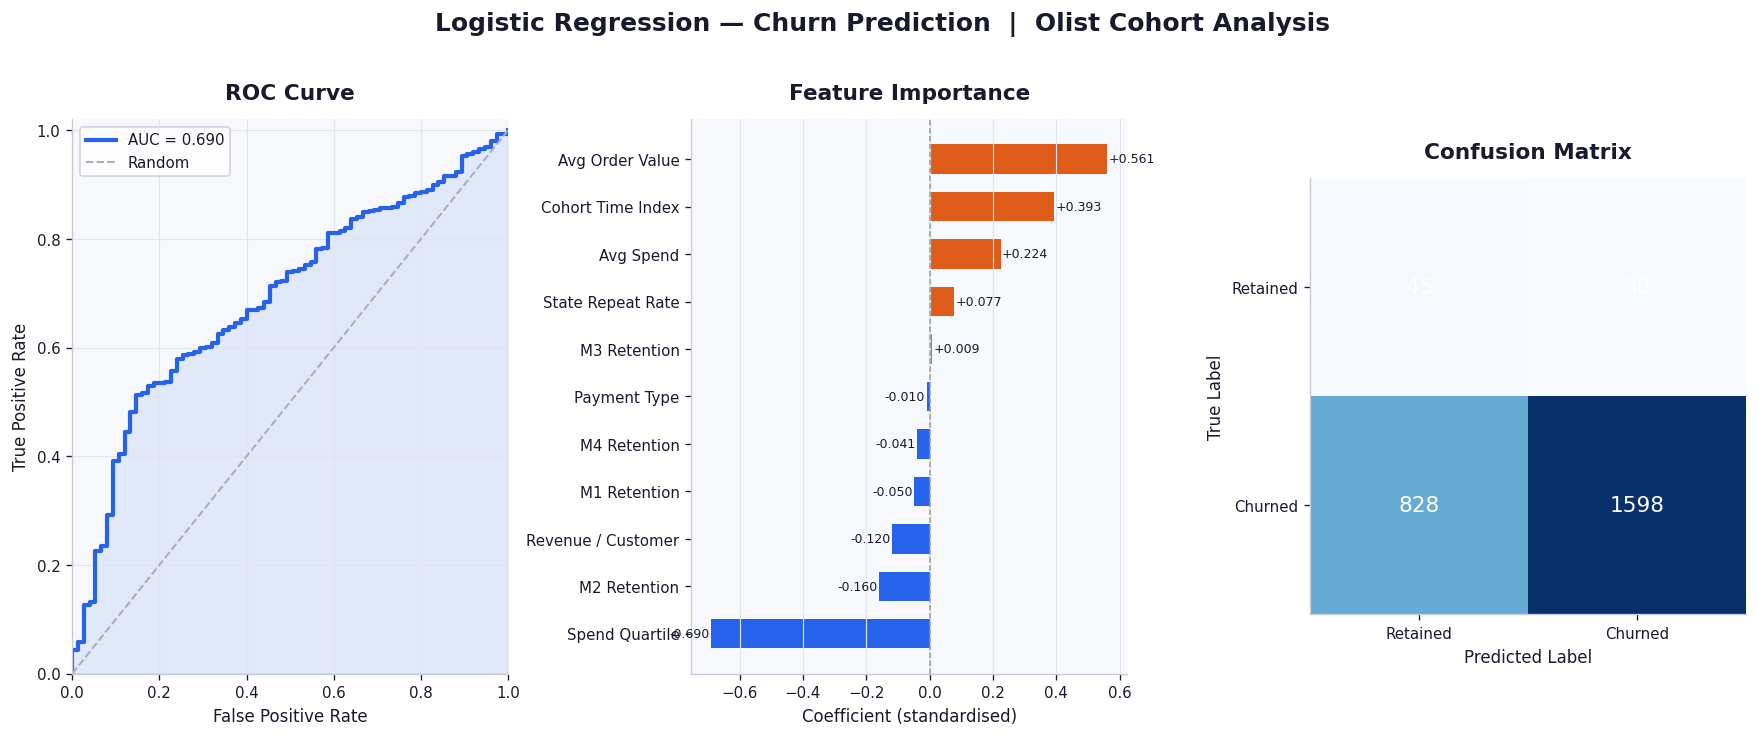

✅ Saved → logistic_regression_churn.png


In [ ]:
# =============================================================================
# CHART 10 — LOGISTIC REGRESSION (Churn Prediction)
# Reconstructs a synthetic customer-level dataset from KPI aggregates, trains a logistic regression model, and plots:
#   • ROC Curve
#   • Feature Importance (coefficients)
#   • Confusion Matrix
# =============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
import matplotlib.gridspec as gridspec

np.random.seed(42)

# ── 1. Load KPIs ─────────────────────────────────────────────────────────────

kpi1  = pd.read_csv("/KPI1.csv")
kpi3  = pd.read_csv("/KPI3.csv")
kpi5  = pd.read_csv("/KPI5.csv")
kpi7  = pd.read_csv("/KPI7.csv")
kpi9  = pd.read_csv("/KPI9.csv")
kpi10 = pd.read_csv("/KPI10.csv")
ret   = pd.read_csv("/retention_pivot.csv")

# ── 2. Build cohort-level lookup tables ──────────────────────────────────────

# KPI1 → cohort time index + repeat rate
kpi1["cohort_month"] = pd.to_datetime(kpi1["cohort_month"])
kpi1 = kpi1.sort_values("cohort_month").reset_index(drop=True)
kpi1["cohort_idx"] = range(len(kpi1))

# KPI5 → avg_order_value, revenue_per_customer (by cohort)
kpi5["cohort_month"] = pd.to_datetime(kpi5["cohort_month"])
cohort_feat = kpi1[["cohort_month", "cohort_idx", "repeat_rate_pct",
                     "cohort_size", "repeat_buyers", "one_time_buyers"]].merge(
    kpi5[["cohort_month", "avg_order_value", "revenue_per_customer"]],
    on="cohort_month", how="left"
)

# KPI10 → dominant payment type per cohort (mode)
kpi10["cohort_month"] = pd.to_datetime(kpi10["cohort_month"])
dominant_payment = (
    kpi10.sort_values("pct_of_cohort_orders", ascending=False)
         .groupby("cohort_month")["payment_type"]
         .first()
         .reset_index()
)
cohort_feat = cohort_feat.merge(dominant_payment, on="cohort_month", how="left")

# KPI9 → quartile distribution
quartile_probs = kpi9.set_index("spend_quartile")["customer_count"] \
                     .div(kpi9["customer_count"].sum()).to_dict()
quartile_avg   = kpi9.set_index("spend_quartile")["avg_spend"].to_dict()

# KPI7 → state-level repeat rate
state_rr      = kpi7.set_index("customer_state")["repeat_rate_pct"].to_dict()
state_pop     = kpi7.set_index("customer_state")["total_customers"].to_dict()
states        = list(state_pop.keys())
state_weights = np.array([state_pop[s] for s in states], dtype=float)
state_weights /= state_weights.sum()

# retention_pivot → M1–M4 per cohort
ret["cohort_month"] = pd.to_datetime(ret["cohort_month"])
ret_feat = ret[["cohort_month", "month_1", "month_2", "month_3", "month_4"]].copy()
ret_feat.columns = ["cohort_month", "M1", "M2", "M3", "M4"]
ret_feat = ret_feat.fillna(0)
cohort_feat = cohort_feat.merge(ret_feat, on="cohort_month", how="left")

# ── 3. Synthesise customer-level rows ────────────────────────────────────────

TARGET_N     = 10_000
sample_frac  = min(1.0, TARGET_N / cohort_feat["cohort_size"].sum())
rows         = []
payment_enc  = {"credit_card": 0, "boleto": 1, "voucher": 2, "debit_card": 3}

for _, c in cohort_feat.iterrows():
    n_total  = int(round(c["cohort_size"]   * sample_frac))
    n_repeat = int(round(c["repeat_buyers"] * sample_frac))
    n_onetime = n_total - n_repeat
    if n_total == 0:
        continue

    labels = np.array([1] * n_repeat + [0] * n_onetime)
    t_idx  = c["cohort_idx"] / (len(cohort_feat) - 1)

    aov_base = c["avg_order_value"] if not np.isnan(c["avg_order_value"]) else 160.0
    aov = np.where(
        labels == 1,
        np.random.normal(aov_base * 0.92, aov_base * 0.15, n_total),
        np.random.normal(aov_base,        aov_base * 0.20, n_total)
    )

    rpc_base = c["revenue_per_customer"] if not np.isnan(c["revenue_per_customer"]) else 165.0
    rpc = np.random.normal(rpc_base, rpc_base * 0.18, n_total)

    q_probs = [quartile_probs[k] for k in [1, 2, 3, 4]]
    spend_q = np.random.choice([1, 2, 3, 4], size=n_total, p=q_probs)
    mask1 = labels == 1
    spend_q[mask1] = np.clip(
        spend_q[mask1] + np.random.choice([0, 1], size=mask1.sum(), p=[0.4, 0.6]), 1, 4
    )
    avg_spend = np.array([quartile_avg[q] for q in spend_q])

    pt_raw  = c["payment_type"] if isinstance(c["payment_type"], str) else "credit_card"
    pt_base = payment_enc.get(pt_raw, 0)
    pt_noise = np.random.choice(list(payment_enc.values()), size=n_total,
                                p=[0.75, 0.18, 0.05, 0.02])
    payment = np.where(np.random.rand(n_total) < 0.80, pt_base, pt_noise)

    sampled_states = np.random.choice(states, size=n_total, p=state_weights)
    state_rr_vals  = np.array([state_rr[s] for s in sampled_states])

    def noisy_ret(base):
        return np.clip(np.random.normal(base, 0.15, n_total), 0, 5)

    m1 = noisy_ret(c["M1"]); m2 = noisy_ret(c["M2"])
    m3 = noisy_ret(c["M3"]); m4 = noisy_ret(c["M4"])

    for i in range(n_total):
        rows.append({
            "cohort_idx":           t_idx,
            "avg_order_value":      aov[i],
            "revenue_per_customer": rpc[i],
            "spend_quartile":       spend_q[i],
            "avg_spend":            avg_spend[i],
            "payment_type_enc":     payment[i],
            "state_repeat_rate":    state_rr_vals[i],
            "M1_retention":         m1[i],
            "M2_retention":         m2[i],
            "M3_retention":         m3[i],
            "M4_retention":         m4[i],
            "churn":                1 - labels[i],
        })

df = pd.DataFrame(rows)
print(f"Synthetic dataset: {len(df):,} customers | "
      f"churn rate = {df['churn'].mean()*100:.1f}%")

# ── 4. Train / Test split + scale ────────────────────────────────────────────

feature_cols = [
    "cohort_idx", "avg_order_value", "revenue_per_customer",
    "spend_quartile", "avg_spend", "payment_type_enc",
    "state_repeat_rate", "M1_retention", "M2_retention",
    "M3_retention", "M4_retention"
]
FEATURE_LABELS = [
    "Cohort Time Index", "Avg Order Value", "Revenue / Customer",
    "Spend Quartile", "Avg Spend", "Payment Type",
    "State Repeat Rate", "M1 Retention", "M2 Retention",
    "M3 Retention", "M4 Retention"
]

X = df[feature_cols].values
y = df["churn"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ── 5. Fit model ─────────────────────────────────────────────────────────────

model = LogisticRegression(max_iter=1000, class_weight="balanced",
                           solver="lbfgs", random_state=42)
model.fit(X_train_s, y_train)

y_pred      = model.predict(X_test_s)
y_prob      = model.predict_proba(X_test_s)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc     = auc(fpr, tpr)
coefs       = model.coef_[0]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

# ── 6. Plot ───────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 6))
fig.patch.set_facecolor("white")
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.42)

BG      = "white"
PANEL   = "#f7f8fc"
ACCENT  = "#2563eb"   # strong blue
ACCENT2 = "#e05c1a"   # warm orange
TEXT    = "#1a1a2e"
GRID    = "#e2e4ed"
SPINE   = "#c8cad6"

def style_ax(ax):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)
    for spine in ax.spines.values():
        spine.set_edgecolor(SPINE)

# ── (a) ROC Curve ─────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
style_ax(ax1)
ax1.plot(fpr, tpr, color=ACCENT, lw=2.5, label=f"AUC = {roc_auc:.3f}")
ax1.plot([0, 1], [0, 1], color="#aab", lw=1.2, linestyle="--", label="Random")
ax1.fill_between(fpr, tpr, alpha=0.10, color=ACCENT)
ax1.set_xlabel("False Positive Rate", fontsize=10, color=TEXT)
ax1.set_ylabel("True Positive Rate",  fontsize=10, color=TEXT)
ax1.set_title("ROC Curve", fontsize=13, fontweight="bold", pad=12, color=TEXT)
ax1.legend(facecolor=BG, edgecolor=SPINE, labelcolor=TEXT, fontsize=9)
ax1.grid(True, color=GRID, linewidth=0.7)
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1.02)

# ── (b) Feature Importance ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
style_ax(ax2)
order         = np.argsort(coefs)
sorted_labels = [FEATURE_LABELS[i] for i in order]
sorted_coefs  = coefs[order]
bar_colors    = [ACCENT2 if v > 0 else ACCENT for v in sorted_coefs]
bars = ax2.barh(sorted_labels, sorted_coefs, color=bar_colors,
                height=0.62, edgecolor="none")
ax2.axvline(0, color="#999", linewidth=0.9, linestyle="--")
ax2.set_xlabel("Coefficient (standardised)", fontsize=10, color=TEXT)
ax2.set_title("Feature Importance", fontsize=13, fontweight="bold", pad=12, color=TEXT)
ax2.grid(True, axis="x", color=GRID, linewidth=0.7)
for bar, val in zip(bars, sorted_coefs):
    offset = 0.004 if val >= 0 else -0.004
    ax2.text(val + offset, bar.get_y() + bar.get_height() / 2,
             f"{val:+.3f}", va="center",
             ha="left" if val >= 0 else "right",
             color=TEXT, fontsize=7.5)

# ── (c) Confusion Matrix ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
style_ax(ax3)
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Retained", "Churned"])
disp.plot(ax=ax3, colorbar=False, cmap=plt.cm.Blues, values_format="d")
ax3.set_title("Confusion Matrix", fontsize=13, fontweight="bold", pad=12, color=TEXT)
ax3.set_xlabel("Predicted Label", fontsize=10, color=TEXT)
ax3.set_ylabel("True Label",      fontsize=10, color=TEXT)
ax3.tick_params(colors=TEXT, labelsize=9)
for txt in disp.text_.ravel():
    txt.set_color("white")
    txt.set_fontsize(13)

fig.suptitle("Logistic Regression — Churn Prediction  |  Olist Cohort Analysis",
             fontsize=15, fontweight="bold", color=TEXT, y=1.03)

plt.savefig("logistic_regression_churn.png",
            dpi=160, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Saved → logistic_regression_churn.png")

Fetching Brazil GeoJSON …
GeoJSON loaded ✅


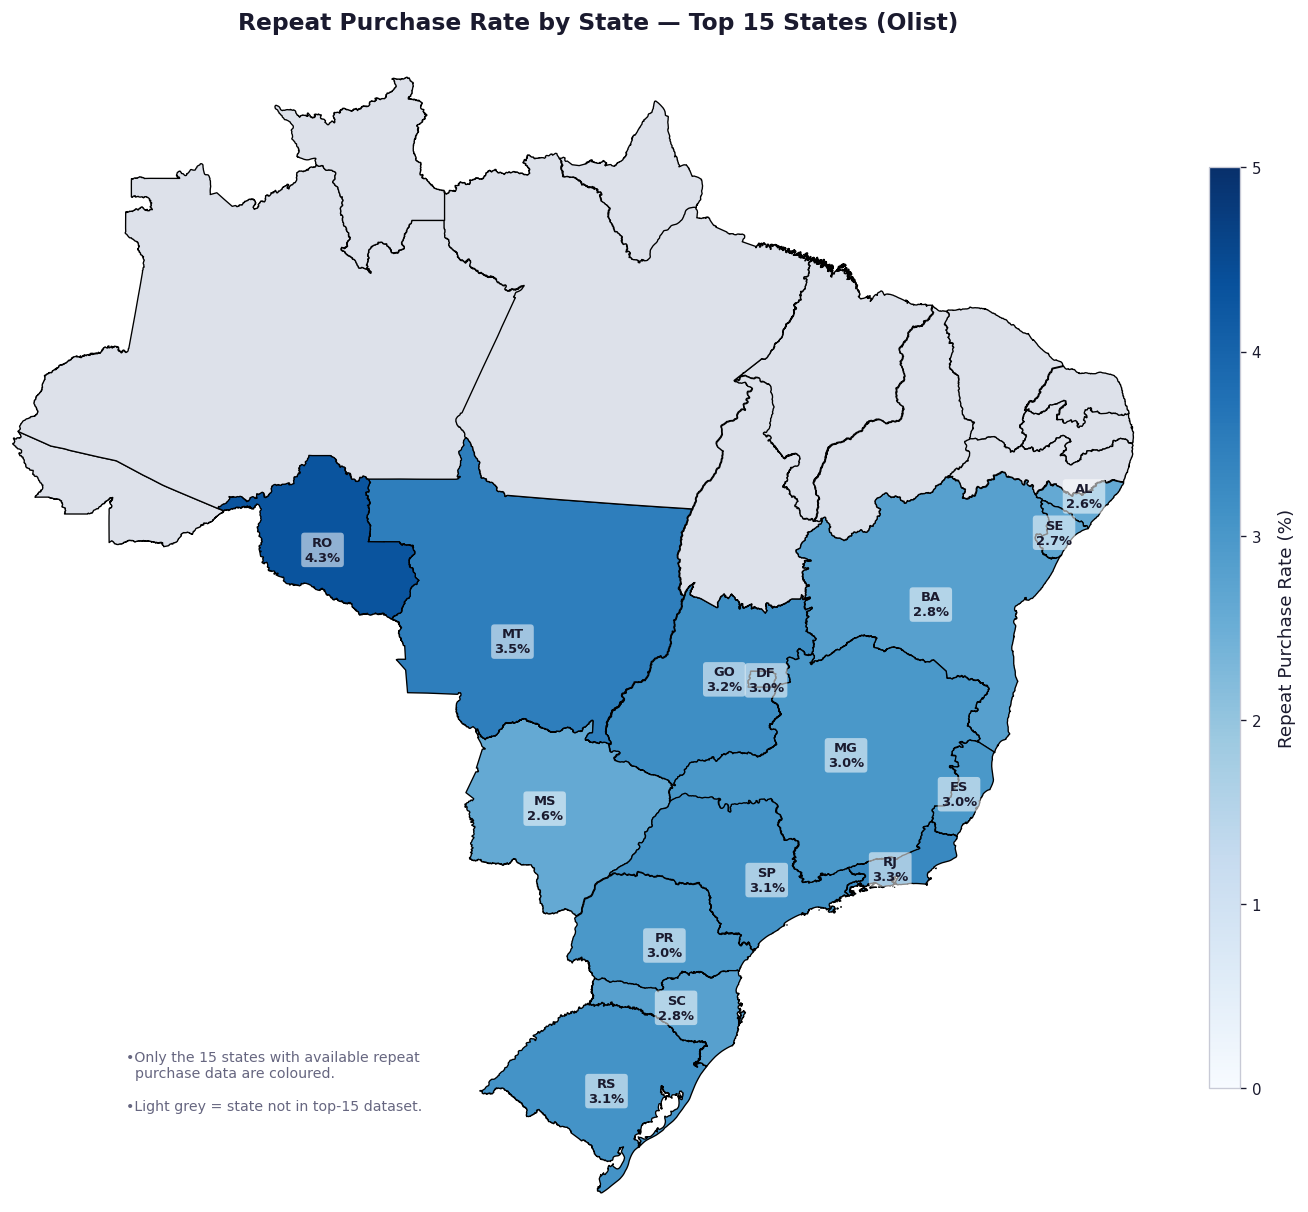

✅ Saved → choropleth_brazil_repeat_rate.png


In [ ]:
# =============================================================================
# CHART 11 — CHOROPLETH: Brazil State Repeat Rate (KPI7)
# =============================================================================

import json, urllib.request
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# ── 1. Load KPI7 ──────────────────────────────────────────────────────────────
kpi7       = pd.read_csv("/KPI7.csv")
state_data = kpi7.set_index("customer_state")["repeat_rate_pct"].to_dict()

# ── 2. Fetch Brazil GeoJSON ────────────────────────────────────────────────────
GEOJSON_URL = (
    "https://raw.githubusercontent.com/codeforamerica/click_that_hood/"
    "master/public/data/brazil-states.geojson"
)
print("Fetching Brazil GeoJSON …")
with urllib.request.urlopen(GEOJSON_URL) as response:
    brazil_geo = json.loads(response.read().decode())
print("GeoJSON loaded ✅")

# ── 3. Map full Portuguese state names → 2-letter codes ──────────────────────
BR_NAME_TO_CODE = {
    "Acre": "AC", "Alagoas": "AL", "Amapá": "AP", "Amazonas": "AM",
    "Bahia": "BA", "Ceará": "CE", "Distrito Federal": "DF",
    "Espírito Santo": "ES", "Goiás": "GO", "Maranhão": "MA",
    "Mato Grosso": "MT", "Mato Grosso do Sul": "MS", "Minas Gerais": "MG",
    "Pará": "PA", "Paraíba": "PB", "Paraná": "PR", "Pernambuco": "PE",
    "Piauí": "PI", "Rio de Janeiro": "RJ", "Rio Grande do Norte": "RN",
    "Rio Grande do Sul": "RS", "Rondônia": "RO", "Roraima": "RR",
    "Santa Catarina": "SC", "São Paulo": "SP", "Sergipe": "SE",
    "Tocantins": "TO"
}

# ── 4. Attach repeat_rate to each GeoJSON feature ────────────────────────────
for feat in brazil_geo["features"]:
    name = feat["properties"].get("name", "")
    code = BR_NAME_TO_CODE.get(name, "")
    feat["properties"]["state_code"]  = code
    feat["properties"]["repeat_rate"] = state_data.get(code, np.nan)

# ── 5. Polygon centroids for state labels ─────────────────────────────────────
def polygon_centroid(coords):
    pts = np.array(coords[0])
    return pts[:, 0].mean(), pts[:, 1].mean()

centroids = {}
for feat in brazil_geo["features"]:
    code = feat["properties"]["state_code"]
    if not code:
        continue
    geom = feat["geometry"]
    if geom["type"] == "Polygon":
        cx, cy = polygon_centroid(geom["coordinates"])
    elif geom["type"] == "MultiPolygon":
        biggest = max(geom["coordinates"], key=lambda p: len(p[0]))
        cx, cy  = polygon_centroid(biggest)
    centroids[code] = (cx, cy)

# ── 6. Draw the choropleth ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 11))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

vmin = 0.0
vmax = 5.0
cmap = plt.cm.Blues
norm = Normalize(vmin=vmin, vmax=vmax)

for feat in brazil_geo["features"]:
    code        = feat["properties"]["state_code"]
    repeat_rate = feat["properties"]["repeat_rate"]
    geom        = feat["geometry"]

    polygons  = []
    poly_list = [geom["coordinates"]] if geom["type"] == "Polygon" \
                else geom["coordinates"]

    for poly_coords in poly_list:
        outer_ring = np.array(poly_coords[0])
        polygons.append(MplPolygon(outer_ring[:, :2], closed=True))

    if np.isnan(repeat_rate):
        face_color = "#dde1ea"   # light grey for no-data states
        edge_color = "black"
    else:
        face_color = cmap(norm(repeat_rate))
        edge_color = "black"

    pc = PatchCollection(polygons, facecolor=face_color,
                         edgecolor=edge_color, linewidth=0.8)
    ax.add_collection(pc)

# State labels — only for KPI7 states (have data)
for code, (cx, cy) in centroids.items():
    rr = state_data.get(code, np.nan)
    if np.isnan(rr):
        continue
    # Choose label colour: white on dark blue, dark on light blue
    label_color = "white" if norm(rr) > 0.55 else "#1a1a2e"
    ax.text(cx, cy, f"{code}\n{rr:.1f}%",
            ha="center", va="center",
            fontsize=7.8, fontweight="bold",
            color="#1a1a2e",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.55))

# Colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02, aspect=30)
cbar.set_label("Repeat Purchase Rate (%)", color="#1a1a2e",
               fontsize=11, labelpad=10)
cbar.ax.yaxis.set_tick_params(color="#1a1a2e", labelsize=9)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#1a1a2e")
cbar.outline.set_edgecolor("#c8cad6")

ax.set_xlim(-74, -33)
ax.set_ylim(-34,   6)
ax.set_aspect("equal")
ax.axis("off")

ax.set_title("Repeat Purchase Rate by State — Top 15 States (Olist)",
             fontsize=14, fontweight="bold", color="#1a1a2e", pad=16)

fig.text(0.1, 0.13,
         "•Only the 15 states with available repeat\n  purchase data are coloured.\n\n"
         "•Light grey = state not in top-15 dataset.",
         color="#666680", fontsize=8.5)

plt.tight_layout()
plt.savefig("choropleth_brazil_repeat_rate.png",
            dpi=160, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Saved → choropleth_brazil_repeat_rate.png")